In [1]:
import os
import avstack
import avapi
from matplotlib import pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

# Importing data
data_base = '../../data'
data_dir_n = os.path.join(data_base, 'nuScenes')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Instantiating Scene Manager
NSM = avapi.nuscenes.nuScenesManager(data_dir_n)

In [3]:
dict = {} # dict for tracking number of objects of each type
frame_idx = 20

# Checking each file in dataset
for i in range(len(NSM.scenes)):
    # Deriving SceneDataset from SceneManager
    NDM = NSM.get_scene_dataset_by_index(scene_idx=i)
    # Get a frame and the objects in that frame
    if NDM.frames is None:
        continue
    frame = NDM.get_frames(sensor="main_camera")[frame_idx]
    objects = NDM.get_objects(frame, sensor='main_lidar')
    # count number of objects of each type (update dict)
    sceneDict = {}
    for obj in objects:
        if dict.get(obj.obj_type):
            dict[obj.obj_type] += 1
        else:
            dict[obj.obj_type] = 1
        
        if sceneDict.get(obj.obj_type):
            sceneDict[obj.obj_type] += 1
        else:
            sceneDict[obj.obj_type] = 1
    print('----Types of objects and # of objects of each type in scene: ', i)
    print(sceneDict)

print('========================================================================================')
print('# of objects of each different type of objects in nuScenes Dataset at frame:', frame_idx)
print(dict)

----Types of objects and # of objects of each type in scene:  0
{'pedestrian': 43, 'car': 10, 'bicycle': 1, 'truck': 5, 'motorcycle': 2, 'bus': 1}
----Types of objects and # of objects of each type in scene:  1
{'pedestrian': 26, 'car': 30, 'motorcycle': 1, 'truck': 1}
----Types of objects and # of objects of each type in scene:  2
{'pedestrian': 11, 'bicycle': 1, 'car': 17, 'bus': 2, 'truck': 2}
----Types of objects and # of objects of each type in scene:  3
{'car': 45, 'truck': 6, 'pedestrian': 3, 'bus': 1}
----Types of objects and # of objects of each type in scene:  4
{'car': 7, 'truck': 2, 'pedestrian': 2, 'bicycle': 1, 'bus': 1}
----Types of objects and # of objects of each type in scene:  5
{'pedestrian': 5, 'motorcycle': 1, 'car': 14}
----Types of objects and # of objects of each type in scene:  6
{'car': 47, 'pedestrian': 9, 'motorcycle': 8, 'truck': 2, 'bus': 1}
----Types of objects and # of objects of each type in scene:  7
{'car': 16, 'bus': 1, 'motorcycle': 1}
----Types of

----Mean number of objects per frame in scene:  0
52.743589743589745
----Standard deviation of objects per frame in scene:  0
8.142065348508448
----Plot of Scene:  0


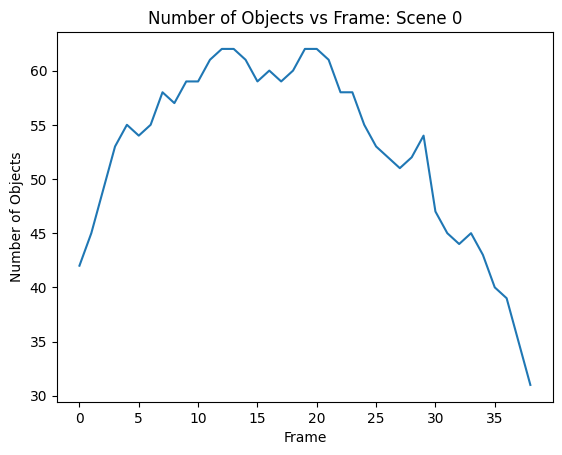

----Mean number of objects per frame in scene:  1
49.9
----Standard deviation of objects per frame in scene:  1
9.873702446397704
----Plot of Scene:  1


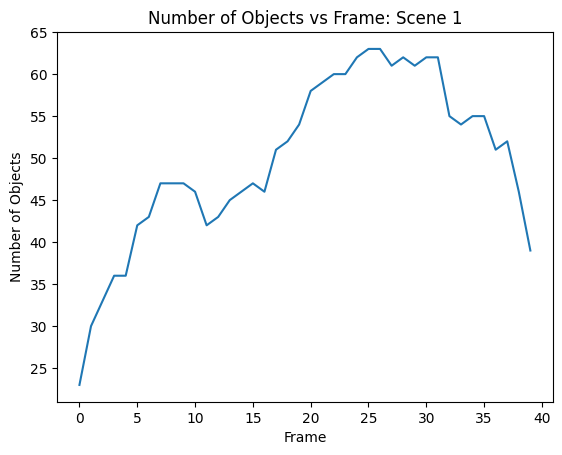

----Mean number of objects per frame in scene:  2
31.097560975609756
----Standard deviation of objects per frame in scene:  2
2.9780078301653066
----Plot of Scene:  2


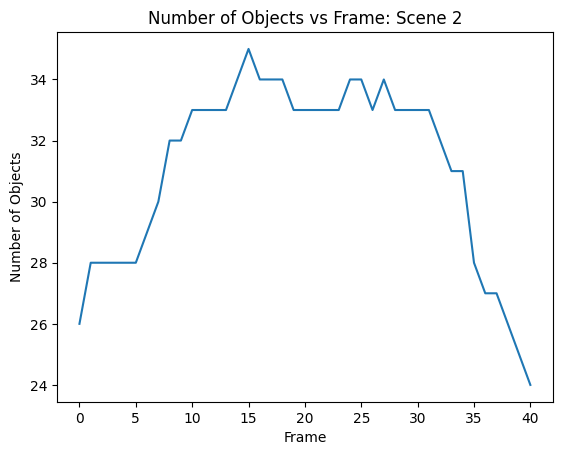

----Mean number of objects per frame in scene:  3
49.707317073170735
----Standard deviation of objects per frame in scene:  3
9.746153468730624
----Plot of Scene:  3


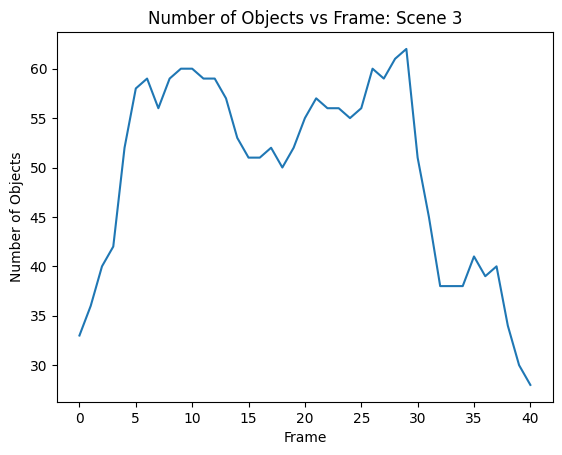

----Mean number of objects per frame in scene:  4
11.292682926829269
----Standard deviation of objects per frame in scene:  4
2.60622053649158
----Plot of Scene:  4


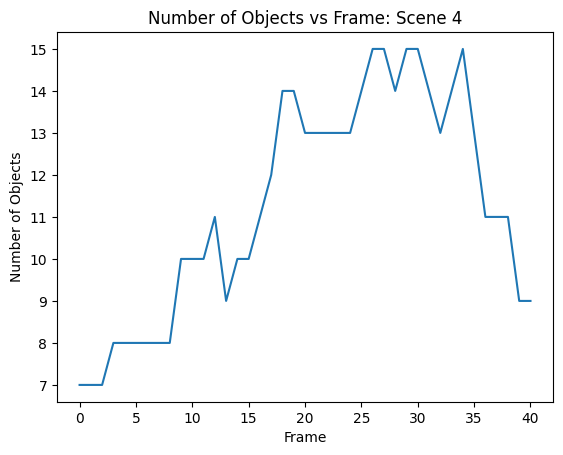

----Mean number of objects per frame in scene:  5
17.8
----Standard deviation of objects per frame in scene:  5
5.577633906953737
----Plot of Scene:  5


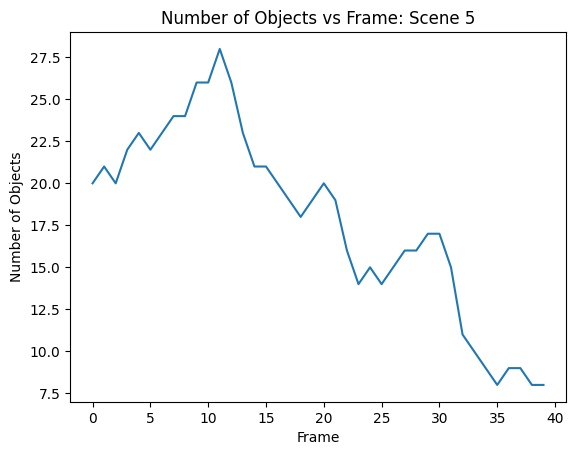

----Mean number of objects per frame in scene:  6
58.68292682926829
----Standard deviation of objects per frame in scene:  6
11.228098517189775
----Plot of Scene:  6


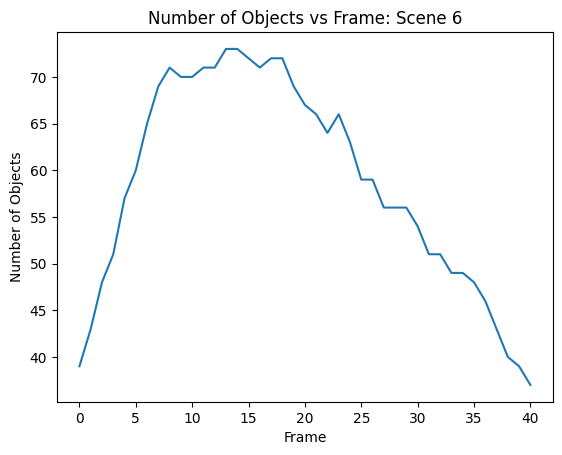

----Mean number of objects per frame in scene:  7
18.365853658536587
----Standard deviation of objects per frame in scene:  7
2.386507781931231
----Plot of Scene:  7


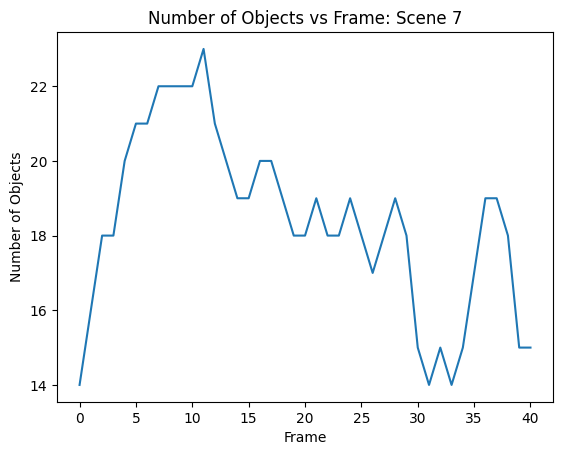

----Mean number of objects per frame in scene:  8
43.775
----Standard deviation of objects per frame in scene:  8
17.772855004191083
----Plot of Scene:  8


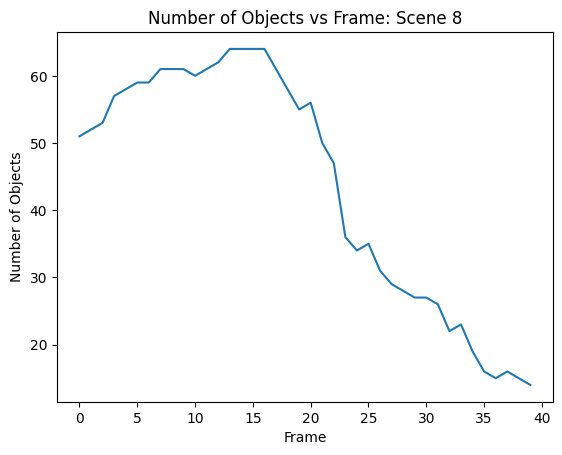

----Mean number of objects per frame in scene:  9
23.9
----Standard deviation of objects per frame in scene:  9
1.0908712114635715
----Plot of Scene:  9


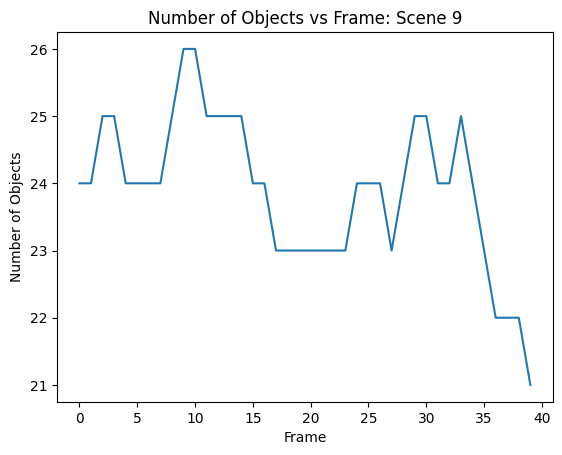

----Mean number of objects per scene:  35.72649312070043
----Standard deviation of objects per scene:  16.30571867717576


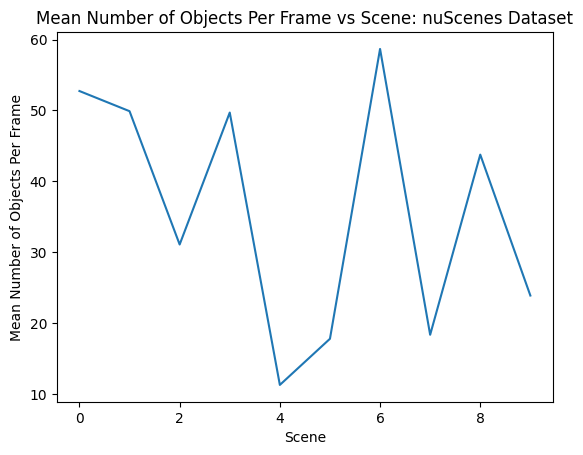

In [6]:
# Plot statistics on objects - what does a scene look like when a car drives around? 
# Mean number of objects per frame, mean number of objects 
# Standard deviation 
# Distribution 
# Make plots in notebook

mean_obj_frame = []

for i in range(len(NSM.scenes)):
    # Deriving SceneDataset from SceneManager
    obj_frame_scene = []
    NDM = NSM.get_scene_dataset_by_index(scene_idx=i)
    for frame_idx in range(len(NDM.frames)):
        frame = NDM.get_frames(sensor="main_camera")[frame_idx]
        objects = NDM.get_objects(frame, sensor='main_lidar')
        obj_frame_scene.append(len(objects))

    mean = np.mean(obj_frame_scene)
    mean_obj_frame.append(mean)
    
    print('----Mean number of objects per frame in scene: ', i)
    print(mean)
    print('----Standard deviation of objects per frame in scene: ', i)
    print(np.std(obj_frame_scene))
    # plot number of objects across frames
    x = list(range(len(obj_frame_scene)))
    y = obj_frame_scene
    print('----Plot of Scene: ', i)
    plt.xlabel('Frame')  
    plt.ylabel('Number of Objects')  
    title = 'Number of Objects vs Frame: Scene ' + str(i)
    plt.title(title) 
    plt.plot(x, y)
    plt.show()

print('----Mean number of objects per scene: ', np.mean(mean_obj_frame)) # not sure if this is the correct way to calculate it (taking mean of mean)

# standard deviation
print('----Standard deviation of objects per scene: ', np.std(mean_obj_frame))

# plot mean number of objects per frame across scenes
x = list(range(len(mean_obj_frame)))
y = mean_obj_frame
plt.xlabel('Scene')  
plt.ylabel('Mean Number of Objects Per Frame')  

# displaying the title 
plt.title("Mean Number of Objects Per Frame vs Scene: nuScenes Dataset") 
plt.plot(x, y)
plt.show()